In [9]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
def forest_plot_helper(axs, data_df, model_df, metric):

    # extract data
    data_point = data_df[f"{metric}_point"].values
    model_lbs = model_df[f"{metric}_lb"].values
    model_ubs = model_df[f"{metric}_ub"].values
    model_point = model_df[f"{metric}_point"].values

    # compute fit relative to data
    relative_lbs = model_lbs - data_point
    relative_ubs = model_ubs - data_point
    relative_point = model_point - data_point

    # forest plot
    for r, (lb, pt, ub) in enumerate(zip(relative_lbs, relative_point, relative_ubs)):
        if lb < 0 and ub > 0:
            color = "green"
        else:
            color = "red"
        axs.plot([lb, ub], [r, r], color=color)
        axs.scatter([pt], [r], color=color, s=5)
        axs.axvline(0, color="black", alpha=0.25)

In [11]:
def forest_plot(data_name, model_name, figsize=(24, 4)):

    # load data
    data_df = pd.read_csv(f"./data/{data_name}.csv")
    model_df = pd.read_csv(f"./data/{data_name}-{model_name}.csv", index_col=0)

    # select metrics
    metrics = [
        "mean_1",
        "mean_2",
        "vars_1",
        "vars_2",
        "prsn",
        "sprm"
    ]
    names = [
        "Mean 1",
        "Mean 2",
        "Variance 1",
        "Variance 2",
        "Pearson Correlation",
        "Spearman Correlation"
    ]

    # plot
    fig, axs = plt.subplots(1, 6, figsize=(24, 4))

    for i, metric in enumerate(metrics):
        forest_plot_helper(axs[i], data_df, model_df, metric)
        axs[i].set_title(names[i])

    fig.supxlabel("Statistic relative to observed data")
    fig.suptitle(f"Posterior Predictive Intervals: (data) {data_name}, (model) {model_name}")
    axs[0].set_ylabel("Repeats")
    
    plt.show()

In [22]:
def compute_coverage(data_name, model_name):

    # load data
    data_df = pd.read_csv(f"./data/{data_name}.csv")
    model_df = pd.read_csv(f"./data/{data_name}-{model_name}.csv", index_col=0)

    # select metrics
    metrics = [
        "mean_1",
        "mean_2",
        "vars_1",
        "vars_2",
        "prsn",
        #"sprm"
    ]

    # compute coverage
    coverage_dict = {}
    for metric in metrics:
        coverage_dict[metric] = np.mean(
            (model_df[f"{metric}_lb"] <= data_df[f"{metric}_point"]) &
            (model_df[f"{metric}_ub"] >= data_df[f"{metric}_point"])
        )
    coverage_dict['total'] = np.mean(list(coverage_dict.values()))
    coverage_df = pd.DataFrame(coverage_dict, index=[0])
    
    return coverage_df

In [23]:
def compute_MSE(data_name, model_name):

    # load data
    data_df = pd.read_csv(f"./data/{data_name}.csv")
    model_df = pd.read_csv(f"./data/{data_name}-{model_name}.csv", index_col=0)

    # select metrics
    metrics = [
        "mean_1",
        "mean_2",
        "vars_1",
        "vars_2",
        "prsn",
        #"sprm"
    ]

    # compute MSE
    MSE_dict = {}
    for metric in metrics:
        MSE_dict[metric] = np.mean((model_df[f"{metric}_point"] - data_df[f"{metric}_point"])**2)
    MSE_dict['total'] = np.mean(list(MSE_dict.values()))
    MSE_df = pd.DataFrame(MSE_dict, index=[0])
    
    return MSE_df

In [24]:
def summary_table(data_names, model_names, rtype):

    table = pd.DataFrame(columns=["data", "model", "mean_1", "mean_2", "vars_1", "vars_2", "prsn", "total"])
    for model_name in model_names:
        for data_name in data_names:
            try:
                if rtype == "coverage":
                    result_df = compute_coverage(data_name, model_name)
                elif rtype == "MSE":
                    result_df = compute_MSE(data_name, model_name)
                else:
                    raise Exception(f"Invalid rtype {rtype}")
            except:
                continue
            result_df["data"] = data_name
            result_df["model"] = model_name
            table = pd.concat([table, result_df], ignore_index=True)

    if rtype == "coverage":
        return table.style.background_gradient(axis=0, subset=["mean_1", "mean_2", "vars_1", "vars_2", "prsn", "total"], vmin=0, vmax=1, cmap="RdYlGn")
    
    elif rtype == "MSE":
        return table.style.background_gradient(axis=0, subset=["mean_1", "mean_2", "vars_1", "vars_2", "prsn", "total"], vmin=0, cmap="RdYlGn_r")

    else:
        return None

In [34]:
def single_metric_summary_table(data_names, model_names, metric, rtype):

    matrix = np.zeros((len(data_names), len(model_names)))
    for i, data_name in enumerate(data_names):
        for j, model_name in enumerate(model_names):
            if rtype == "coverage":
                result_df = compute_coverage(data_name, model_name)
            elif rtype == "MSE":
                result_df = compute_MSE(data_name, model_name)
            else:
                raise Exception(f"Invalid rtype {rtype}")
            matrix[i, j] = result_df[metric].item()
    
    table = pd.DataFrame(
        matrix,
        columns=model_names,
        index=data_names
    )

    if rtype == "coverage":
        return table.style.background_gradient(axis=1, vmin=0, vmax=1, cmap="RdYlGn")
    
    elif rtype == "MSE":
        return table.style.background_gradient(axis=1, vmin=0, cmap="RdYlGn_r")

    else:
        return None

In [40]:
# correctly apply row wise
pd.DataFrame([[0.5, 0.1, 0.0], [1, 10, 100]]).style.background_gradient(axis=1)

,0,1,2
0,0.500000,0.100000,0.000000
1,1.000000,10.000000,100.000000


# (1) Default fit

- NB model with observed library size
- all 7 datas
- 3 model sizes: 128, 16, 4 neurons in hidden layer (1 layer, 2 latent dim)

Summary
- model size
    - smaller model has better overall fit (strange)
    - larger model has better correlation fit
    - but smaller effect than data
- data
    - good performance on real data, especially correlation
    - lognormal is best fit simulated data, except poor correlation
        - EM-VAE-scVI comparison work supports good fit, but suggests correlation fit may be parameter dependent
    - poor performance on other simulated data
        - only mean fit well by smaller model
- note
    - mainly look at coverage, MSE generally supports conclusions but maybe need to compute relative values e.g. variance vs correlation very different scale but just combined
    - also computed spearman correlation, but not included as ~0% coverage being almost always overestimated

## Coverage

### Total

In [35]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400"],
    "total",
    "coverage"
)

,NB-128-2-1-400,NB-16-2-1-400,NB-4-2-1-400
real-data,0.640000,0.753333,0.740000
lognormal-nb,0.773333,0.806667,0.766667
lognormal-poi,0.620000,0.726667,0.753333
copula-nb,0.160000,0.273333,0.366667
copula-poi,0.146667,0.333333,0.360000
indep-nb,0.220000,0.246667,0.446667
indep-poi,0.153333,0.286667,0.386667


### Correlation

In [36]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400"],
    "prsn",
    "coverage"
)

,NB-128-2-1-400,NB-16-2-1-400,NB-4-2-1-400
real-data,0.766667,0.766667,0.333333
lognormal-nb,0.466667,0.300000,0.066667
lognormal-poi,0.366667,0.233333,0.000000
copula-nb,0.000000,0.000000,0.000000
copula-poi,0.033333,0.033333,0.033333
indep-nb,0.133333,0.000000,0.000000
indep-poi,0.000000,0.000000,0.000000


### Per statistic

In [ ]:
summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400"],
    "coverage"
)

,data,model,mean_1,mean_2,vars_1,vars_2,prsn,total
0,real-data,NB-128-2-1-400,0.600000,0.666667,0.666667,0.500000,0.766667,0.640000
1,lognormal-nb,NB-128-2-1-400,0.766667,0.766667,0.866667,1.000000,0.466667,0.773333
2,lognormal-poi,NB-128-2-1-400,0.633333,0.633333,0.666667,0.800000,0.366667,0.620000
3,copula-nb,NB-128-2-1-400,0.400000,0.400000,0.000000,0.000000,0.000000,0.160000
4,copula-poi,NB-128-2-1-400,0.366667,0.333333,0.000000,0.000000,0.033333,0.146667
5,indep-nb,NB-128-2-1-400,0.433333,0.400000,0.033333,0.100000,0.133333,0.220000
6,indep-poi,NB-128-2-1-400,0.366667,0.400000,0.000000,0.000000,0.000000,0.153333
7,real-data,NB-16-2-1-400,0.766667,0.800000,0.666667,0.766667,0.766667,0.753333
8,lognormal-nb,NB-16-2-1-400,0.966667,0.933333,0.900000,0.933333,0.300000,0.806667
9,lognormal-poi,NB-16-2-1-400,0.966667,0.966667,0.700000,0.766667,0.233333,0.726667


## MSE

### Total

In [30]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400"],
    "total",
    "MSE"
)

,NB-128-2-1-400,NB-16-2-1-400,NB-4-2-1-400
real-data,48.980893,17.434338,9.679578
lognormal-nb,1.166152,3.476463,0.913160
lognormal-poi,0.260912,0.206869,0.126258
copula-nb,8.582585,8.174246,7.609118
copula-poi,12.209044,12.095769,11.967051
indep-nb,5.540108,4.524461,2.207890
indep-poi,6.065991,5.766137,5.672511


### Correlation

In [31]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400"],
    "prsn",
    "MSE"
)

,NB-128-2-1-400,NB-16-2-1-400,NB-4-2-1-400
real-data,0.002350,0.001321,0.010608
lognormal-nb,0.000364,0.000736,0.003650
lognormal-poi,0.001066,0.001264,0.006527
copula-nb,0.020028,0.021846,0.026654
copula-poi,0.080239,0.080924,0.084647
indep-nb,0.001061,0.000969,0.002904
indep-poi,0.103193,0.109882,0.111704


### Per statistic

In [ ]:
summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400"],
    "MSE"
)

,data,model,mean_1,mean_2,vars_1,vars_2,prsn,total
0,real-data,NB-128-2-1-400,0.007680,0.007660,105.374380,139.512393,0.002350,48.980893
1,lognormal-nb,NB-128-2-1-400,0.000458,0.000452,1.185913,4.643572,0.000364,1.166152
2,lognormal-poi,NB-128-2-1-400,0.000556,0.000545,0.685813,0.616579,0.001066,0.260912
3,copula-nb,NB-128-2-1-400,0.017498,0.017579,21.636953,21.220867,0.020028,8.582585
4,copula-poi,NB-128-2-1-400,0.007425,0.007421,30.695723,30.254410,0.080239,12.209044
5,indep-nb,NB-128-2-1-400,0.006238,0.006128,12.644599,15.042512,0.001061,5.540108
6,indep-poi,NB-128-2-1-400,0.010868,0.010997,14.760973,15.443920,0.103193,6.065991
7,real-data,NB-16-2-1-400,0.001641,0.001572,26.225262,60.941892,0.001321,17.434338
8,lognormal-nb,NB-16-2-1-400,0.000128,0.000129,1.131095,16.250226,0.000736,3.476463
9,lognormal-poi,NB-16-2-1-400,0.000146,0.000141,0.513575,0.519220,0.001264,0.206869


## Example plots

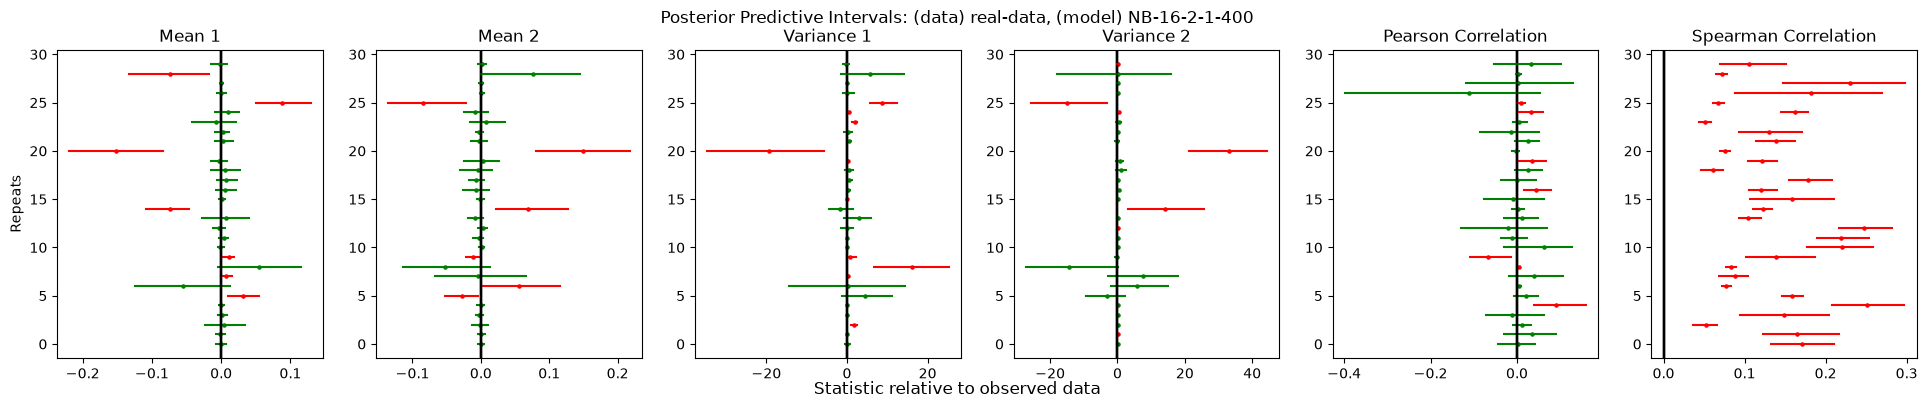

In [41]:
forest_plot("real-data", "NB-16-2-1-400")

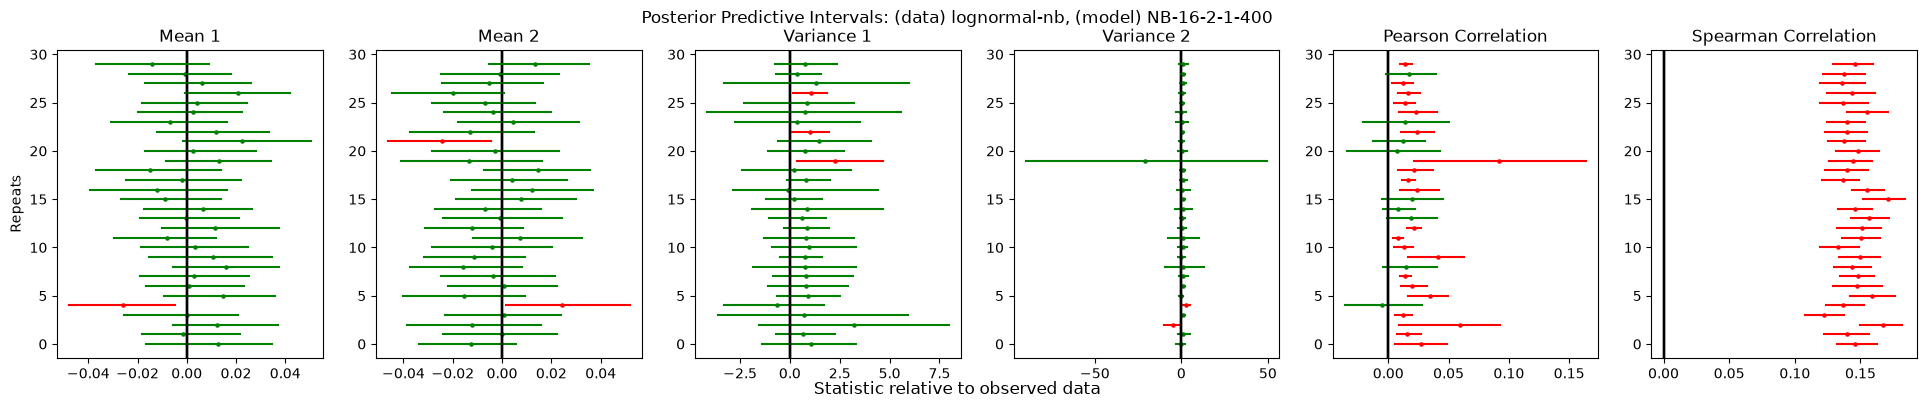

In [42]:
forest_plot("lognormal-nb", "NB-16-2-1-400")

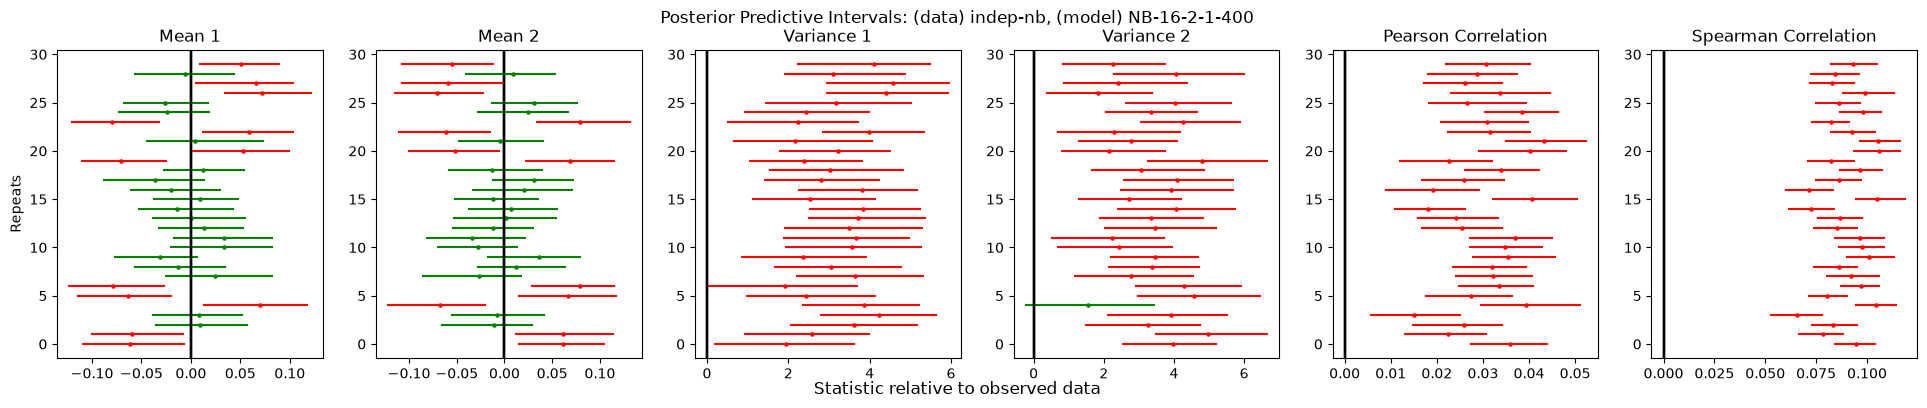

In [62]:
forest_plot("indep-nb", "NB-16-2-1-400")

# (2) Library Size Choices

- real data
- NB (16, 2, 1) model
- 5 library size choices:
    - observed (over 2 genes)
    - `const` fixed constant (equal to observed mean)
    - `real` fixed real (observed library size from larger gene set, rescaled to match observed mean)
    - `pad` observed with constant gene padding (gene with x = 1 so l >= 1)
    - `soft` fix to observed, so same value but softplus activation not softmax

Summary
- padding similar if not better than default observed
    - correlation better
- fixed values
    - fixing to observed i.e. only changing softmax -> softplus, has little effectm slightly worse correlation
    - other fixed values much worse, especially for correlation
    - fixed to observed >> constant ~> real

(Softmax maybe not the issue)
(really seem to need observed libarary size to fit the correlation well: perhaps because correlation so determined by cell - cell variability?)

## Coverage

In [59]:
summary_table(
    ["real-data"],
    ["NB-16-2-1-400", "NB-16-2-1-400-pad", "NB-16-2-1-400-const", "NB-16-2-1-400-real", "NB-16-2-1-400-soft"],
    "coverage"
)

,data,model,mean_1,mean_2,vars_1,vars_2,prsn,total
0,real-data,NB-16-2-1-400,0.766667,0.800000,0.666667,0.766667,0.766667,0.753333
1,real-data,NB-16-2-1-400-pad,0.700000,0.833333,0.700000,0.633333,0.800000,0.733333
2,real-data,NB-16-2-1-400-const,0.400000,0.466667,0.366667,0.400000,0.233333,0.373333
3,real-data,NB-16-2-1-400-real,0.566667,0.600000,0.500000,0.500000,0.200000,0.473333
4,real-data,NB-16-2-1-400-soft,0.833333,0.866667,0.600000,0.766667,0.666667,0.746667


## MSE

In [60]:
summary_table(
    ["real-data"],
    ["NB-16-2-1-400", "NB-16-2-1-400-pad", "NB-16-2-1-400-const", "NB-16-2-1-400-real", "NB-16-2-1-400-soft"],
    "MSE"
)

,data,model,mean_1,mean_2,vars_1,vars_2,prsn,total
0,real-data,NB-16-2-1-400,0.001641,0.001572,26.225262,60.941892,0.001321,17.434338
1,real-data,NB-16-2-1-400-pad,0.002710,0.002861,43.210284,61.689794,0.008646,20.982859
2,real-data,NB-16-2-1-400-const,0.029488,0.037267,963.502858,716.321375,0.094670,335.997132
3,real-data,NB-16-2-1-400-real,0.422977,1.206114,73391.021067,482111.323694,0.119379,111100.818646
4,real-data,NB-16-2-1-400-soft,0.000629,0.000734,4.060719,10.187761,0.001666,2.850302


## Example plots

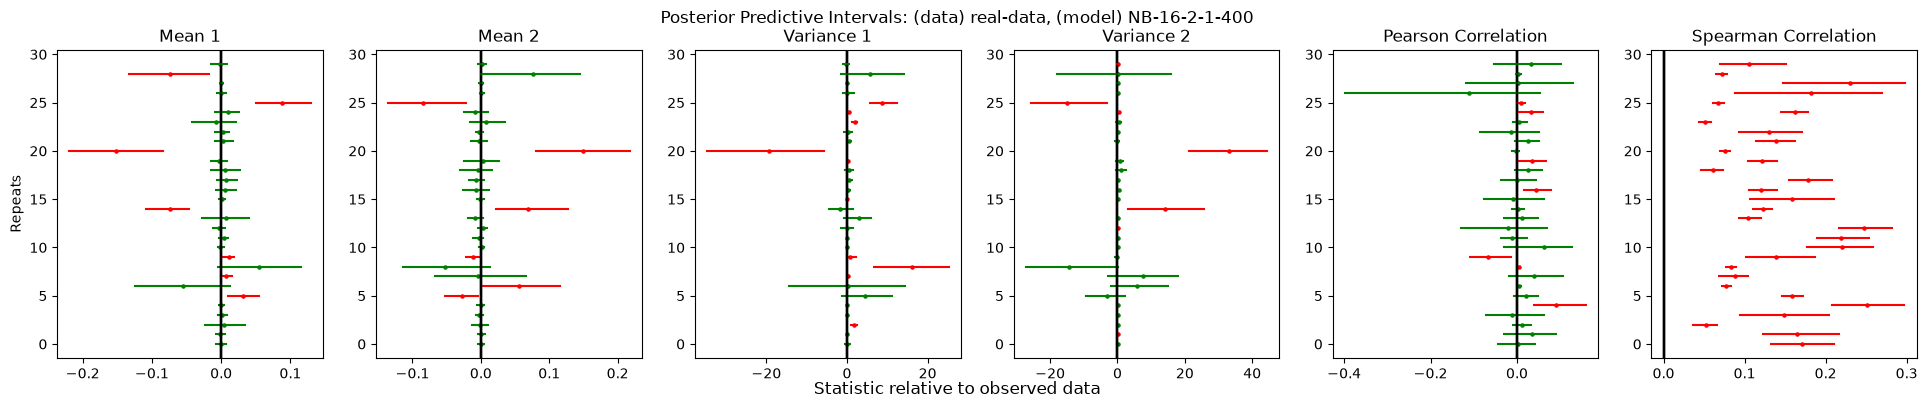

In [45]:
forest_plot("real-data", "NB-16-2-1-400")

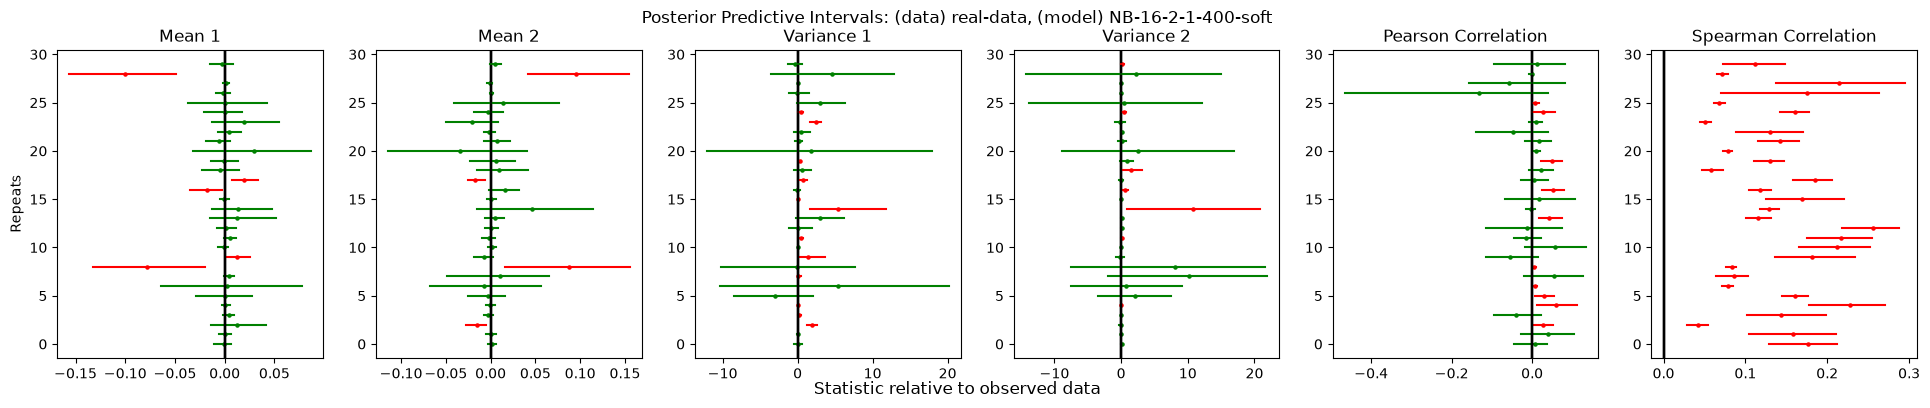

In [61]:
forest_plot("real-data", "NB-16-2-1-400-soft")

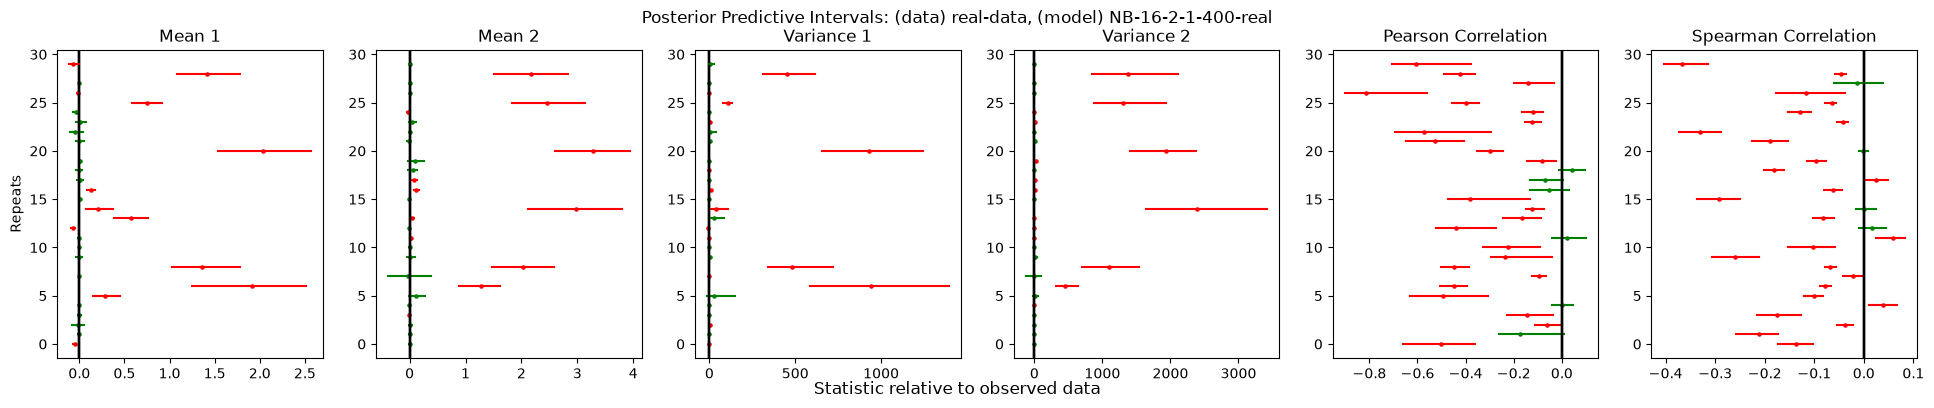

In [46]:
forest_plot("real-data", "NB-16-2-1-400-real")

# (3) Poisson (padding)

- all 7 datas
- 3 models: NB, NB (pad), Poi (pad)
- each with 3 model sizes

Summary
- model size
    - middle > small > large
    - but little difference
- model type
    - NB > NB (pad) > Poisson (pad) overall
    - even for e.g. lognormal poisson data
    - but NB (pad) > Poi (pad) >> NB for correlation on lognormal data

Suggests a relaxation of the l * softmax parametrization can achieve better correlation fits?

## Coverage

In [48]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-16-2-1-400", "NB-16-2-1-400-pad", "Poi-16-2-1-400-pad"],
    "total",
    "coverage"
)

,NB-16-2-1-400,NB-16-2-1-400-pad,Poi-16-2-1-400-pad
real-data,0.753333,0.733333,0.726667
lognormal-nb,0.806667,0.813333,0.780000
lognormal-poi,0.726667,0.626667,0.613333
copula-nb,0.273333,0.253333,0.300000
copula-poi,0.333333,0.306667,0.306667
indep-nb,0.246667,0.333333,0.293333
indep-poi,0.286667,0.246667,0.253333


In [57]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-16-2-1-400", "NB-16-2-1-400-pad", "Poi-16-2-1-400-pad"],
    "prsn",
    "coverage"
)

,NB-16-2-1-400,NB-16-2-1-400-pad,Poi-16-2-1-400-pad
real-data,0.766667,0.800000,0.666667
lognormal-nb,0.300000,0.800000,0.766667
lognormal-poi,0.233333,0.566667,0.566667
copula-nb,0.000000,0.100000,0.133333
copula-poi,0.033333,0.066667,0.100000
indep-nb,0.000000,0.300000,0.366667
indep-poi,0.000000,0.000000,0.000000


In [47]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400", "NB-128-2-1-400-pad", "NB-16-2-1-400-pad", "NB-4-2-1-400-pad", "Poi-128-2-1-400-pad", "Poi-16-2-1-400-pad", "Poi-4-2-1-400-pad"],
    "total",
    "coverage"
)

,NB-128-2-1-400,NB-16-2-1-400,NB-4-2-1-400,NB-128-2-1-400-pad,NB-16-2-1-400-pad,NB-4-2-1-400-pad,Poi-128-2-1-400-pad,Poi-16-2-1-400-pad,Poi-4-2-1-400-pad
real-data,0.640000,0.753333,0.740000,0.573333,0.733333,0.713333,0.500000,0.726667,0.566667
lognormal-nb,0.773333,0.806667,0.766667,0.673333,0.813333,0.806667,0.593333,0.780000,0.726667
lognormal-poi,0.620000,0.726667,0.753333,0.553333,0.626667,0.520000,0.560000,0.613333,0.520000
copula-nb,0.160000,0.273333,0.366667,0.133333,0.253333,0.273333,0.186667,0.300000,0.346667
copula-poi,0.146667,0.333333,0.360000,0.213333,0.306667,0.293333,0.193333,0.306667,0.360000
indep-nb,0.220000,0.246667,0.446667,0.266667,0.333333,0.420000,0.246667,0.293333,0.353333
indep-poi,0.153333,0.286667,0.386667,0.160000,0.246667,0.273333,0.106667,0.253333,0.320000


In [55]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400", "NB-128-2-1-400-pad", "NB-16-2-1-400-pad", "NB-4-2-1-400-pad", "Poi-128-2-1-400-pad", "Poi-16-2-1-400-pad", "Poi-4-2-1-400-pad"],
    "prsn",
    "coverage"
)

,NB-128-2-1-400,NB-16-2-1-400,NB-4-2-1-400,NB-128-2-1-400-pad,NB-16-2-1-400-pad,NB-4-2-1-400-pad,Poi-128-2-1-400-pad,Poi-16-2-1-400-pad,Poi-4-2-1-400-pad
real-data,0.766667,0.766667,0.333333,0.733333,0.800000,0.466667,0.633333,0.666667,0.366667
lognormal-nb,0.466667,0.300000,0.066667,0.600000,0.800000,0.566667,0.700000,0.766667,0.633333
lognormal-poi,0.366667,0.233333,0.000000,0.633333,0.566667,0.466667,0.533333,0.566667,0.433333
copula-nb,0.000000,0.000000,0.000000,0.033333,0.100000,0.100000,0.066667,0.133333,0.133333
copula-poi,0.033333,0.033333,0.033333,0.066667,0.066667,0.100000,0.100000,0.100000,0.066667
indep-nb,0.133333,0.000000,0.000000,0.366667,0.300000,0.866667,0.300000,0.366667,0.800000
indep-poi,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## MSE

In [50]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-16-2-1-400", "NB-16-2-1-400-pad", "Poi-16-2-1-400-pad"],
    "total",
    "MSE"
)

,NB-16-2-1-400,NB-16-2-1-400-pad,Poi-16-2-1-400-pad
real-data,17.434338,20.982859,12.782689
lognormal-nb,3.476463,0.730960,0.840725
lognormal-poi,0.206869,0.338434,0.398610
copula-nb,8.174246,4.102766,4.091598
copula-poi,12.095769,9.419426,9.344291
indep-nb,4.524461,5.785802,6.199520
indep-poi,5.766137,4.507422,4.468293


In [58]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-16-2-1-400", "NB-16-2-1-400-pad", "Poi-16-2-1-400-pad"],
    "prsn",
    "MSE"
)

,NB-16-2-1-400,NB-16-2-1-400-pad,Poi-16-2-1-400-pad
real-data,0.001321,0.008646,0.004347
lognormal-nb,0.000736,0.000115,0.000086
lognormal-poi,0.001264,0.000419,0.000516
copula-nb,0.021846,0.018347,0.018154
copula-poi,0.080924,0.082350,0.082645
indep-nb,0.000969,0.000234,0.000181
indep-poi,0.109882,0.091132,0.090862


In [49]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400", "NB-128-2-1-400-pad", "NB-16-2-1-400-pad", "NB-4-2-1-400-pad", "Poi-128-2-1-400-pad", "Poi-16-2-1-400-pad", "Poi-4-2-1-400-pad"],
    "total",
    "MSE"
)

,NB-128-2-1-400,NB-16-2-1-400,NB-4-2-1-400,NB-128-2-1-400-pad,NB-16-2-1-400-pad,NB-4-2-1-400-pad,Poi-128-2-1-400-pad,Poi-16-2-1-400-pad,Poi-4-2-1-400-pad
real-data,48.980893,17.434338,9.679578,80.741050,20.982859,74.143214,14.230815,12.782689,44.558026
lognormal-nb,1.166152,3.476463,0.913160,10.736912,0.730960,4.965742,3.869455,0.840725,2.436589
lognormal-poi,0.260912,0.206869,0.126258,0.491334,0.338434,0.974010,0.304715,0.398610,0.888396
copula-nb,8.582585,8.174246,7.609118,4.316998,4.102766,3.757184,4.190974,4.091598,3.707238
copula-poi,12.209044,12.095769,11.967051,9.551174,9.419426,9.297759,9.473357,9.344291,9.197156
indep-nb,5.540108,4.524461,2.207890,6.252096,5.785802,8.140437,5.554896,6.199520,8.629248
indep-poi,6.065991,5.766137,5.672511,4.703510,4.507422,4.424191,4.783410,4.468293,4.360462


In [56]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400", "NB-128-2-1-400-pad", "NB-16-2-1-400-pad", "NB-4-2-1-400-pad", "Poi-128-2-1-400-pad", "Poi-16-2-1-400-pad", "Poi-4-2-1-400-pad"],
    "prsn",
    "MSE"
)

,NB-128-2-1-400,NB-16-2-1-400,NB-4-2-1-400,NB-128-2-1-400-pad,NB-16-2-1-400-pad,NB-4-2-1-400-pad,Poi-128-2-1-400-pad,Poi-16-2-1-400-pad,Poi-4-2-1-400-pad
real-data,0.002350,0.001321,0.010608,0.005261,0.008646,0.015380,0.014564,0.004347,0.009361
lognormal-nb,0.000364,0.000736,0.003650,0.001081,0.000115,0.001499,0.000633,0.000086,0.000438
lognormal-poi,0.001066,0.001264,0.006527,0.000523,0.000419,0.002384,0.000614,0.000516,0.001436
copula-nb,0.020028,0.021846,0.026654,0.017826,0.018347,0.022141,0.018045,0.018154,0.022055
copula-poi,0.080239,0.080924,0.084647,0.080872,0.082350,0.086376,0.081948,0.082645,0.087013
indep-nb,0.001061,0.000969,0.002904,0.000401,0.000234,0.000041,0.000534,0.000181,0.000054
indep-poi,0.103193,0.109882,0.111704,0.086680,0.091132,0.093329,0.083527,0.090862,0.093765


# (4) Real data (fixed real)

- real data
- 3 model sizes for NB & Poi
- library size fixed to observed library size from a larger gene set (mean rescaled to 2 gene observed mean)

Summary
- overall poor performance, especially correlation

Suggests, along with (2), that fixed library sizes poor
- either due to parametrization (softplus)
- or need some observed library size to properly model cell - cell variability

In [51]:
summary_table(
    ["real-data"],
    ["NB-128-2-1-400-real", "NB-16-2-1-400-real", "NB-4-2-1-400-real", "Poi-128-2-1-400-real", "Poi-16-2-1-400-real", "Poi-4-2-1-400-real"],
    "coverage"
)

,data,model,mean_1,mean_2,vars_1,vars_2,prsn,total
0,real-data,NB-128-2-1-400-real,0.466667,0.500000,0.466667,0.366667,0.300000,0.420000
1,real-data,NB-16-2-1-400-real,0.566667,0.600000,0.500000,0.500000,0.200000,0.473333
2,real-data,NB-4-2-1-400-real,0.533333,0.500000,0.433333,0.400000,0.066667,0.386667
3,real-data,Poi-128-2-1-400-real,0.466667,0.300000,0.266667,0.233333,0.333333,0.320000
4,real-data,Poi-16-2-1-400-real,0.600000,0.533333,0.266667,0.333333,0.266667,0.400000
5,real-data,Poi-4-2-1-400-real,0.433333,0.466667,0.133333,0.133333,0.100000,0.253333


In [52]:
summary_table(
    ["real-data"],
    ["NB-128-2-1-400-real", "NB-16-2-1-400-real", "NB-4-2-1-400-real", "Poi-128-2-1-400-real", "Poi-16-2-1-400-real", "Poi-4-2-1-400-real"],
    "MSE"
)

,data,model,mean_1,mean_2,vars_1,vars_2,prsn,total
0,real-data,NB-128-2-1-400-real,0.390675,0.734276,54080.965744,236230.785778,0.105613,58062.596417
1,real-data,NB-16-2-1-400-real,0.422977,1.206114,73391.021067,482111.323694,0.119379,111100.818646
2,real-data,NB-4-2-1-400-real,0.383656,0.679285,104917.380616,342971.721611,0.169811,89578.066996
3,real-data,Poi-128-2-1-400-real,0.025745,0.057219,944.001360,3869.675409,0.010727,962.754092
4,real-data,Poi-16-2-1-400-real,0.025149,0.031634,2213.190241,3791.479115,0.011652,1200.947558
5,real-data,Poi-4-2-1-400-real,0.012580,0.010440,305.822621,1355.574962,0.034451,332.291011


# Old

## Coverage table

In [31]:
summary_table(
    ["real-data", "lognormal-nb", "copula-nb", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400"]
)

,data,model,mean_1,mean_2,vars_1,vars_2,prsn,total
0,real-data,NB-128-2-1-400,0.600000,0.666667,0.666667,0.500000,0.766667,0.640000
1,lognormal-nb,NB-128-2-1-400,0.766667,0.766667,0.866667,1.000000,0.466667,0.773333
2,copula-nb,NB-128-2-1-400,0.400000,0.400000,0.000000,0.000000,0.000000,0.160000
3,indep-nb,NB-128-2-1-400,0.433333,0.400000,0.033333,0.100000,0.133333,0.220000
4,indep-poi,NB-128-2-1-400,0.366667,0.400000,0.000000,0.000000,0.000000,0.153333
5,real-data,NB-16-2-1-400,0.766667,0.800000,0.666667,0.766667,0.766667,0.753333
6,lognormal-nb,NB-16-2-1-400,0.966667,0.933333,0.900000,0.933333,0.300000,0.806667
7,copula-nb,NB-16-2-1-400,0.666667,0.700000,0.000000,0.000000,0.000000,0.273333
8,indep-nb,NB-16-2-1-400,0.600000,0.600000,0.000000,0.033333,0.000000,0.246667
9,indep-poi,NB-16-2-1-400,0.700000,0.733333,0.000000,0.000000,0.000000,0.286667


Summary
- smaller model performs better overall: should be enough training time, maybe not
- good performance on real data
- best performance on lognormal data: EM-VAE-scVI comparison work supports this
- except for correlation: fit much better on real data
- poor performance on other simulated data: smaller model fits means better but still fails badly on all else

Note
- not included is spearman correlation, which has ~0% coverage being almost always overestimated

### Example plots

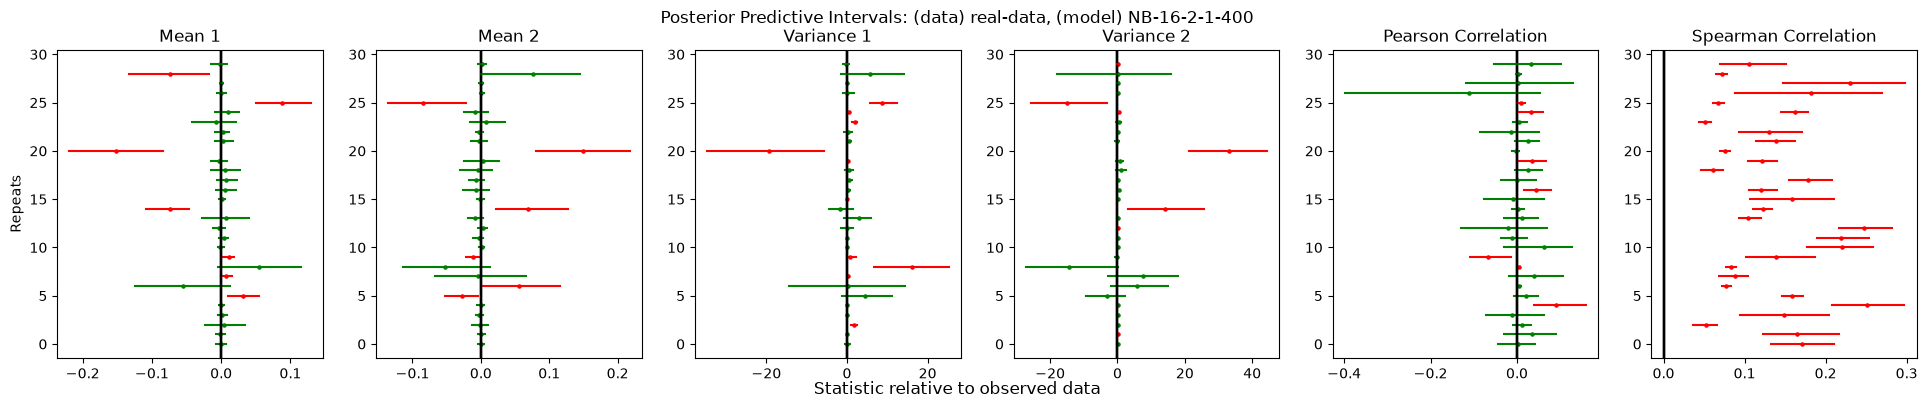

In [32]:
forest_plot("real-data", "NB-16-2-1-400")

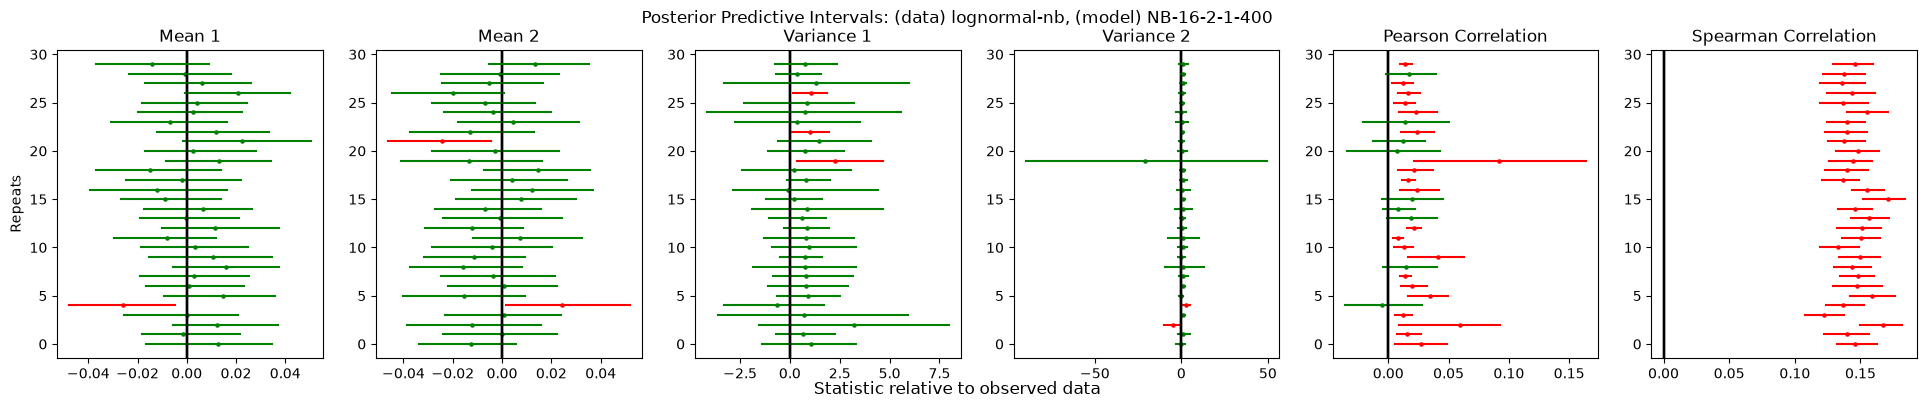

In [33]:
forest_plot("lognormal-nb", "NB-16-2-1-400")

## Updates

- larger models fit correlation better
- smaller models fit better overall

In [7]:
summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400"]
)

,data,model,mean_1,mean_2,vars_1,vars_2,prsn,total
0,real-data,NB-128-2-1-400,0.600000,0.666667,0.666667,0.500000,0.766667,0.640000
1,lognormal-nb,NB-128-2-1-400,0.766667,0.766667,0.866667,1.000000,0.466667,0.773333
2,lognormal-poi,NB-128-2-1-400,0.633333,0.633333,0.666667,0.800000,0.366667,0.620000
3,copula-nb,NB-128-2-1-400,0.400000,0.400000,0.000000,0.000000,0.000000,0.160000
4,copula-poi,NB-128-2-1-400,0.366667,0.333333,0.000000,0.000000,0.033333,0.146667
5,indep-nb,NB-128-2-1-400,0.433333,0.400000,0.033333,0.100000,0.133333,0.220000
6,indep-poi,NB-128-2-1-400,0.366667,0.400000,0.000000,0.000000,0.000000,0.153333
7,real-data,NB-16-2-1-400,0.766667,0.800000,0.666667,0.766667,0.766667,0.753333
8,lognormal-nb,NB-16-2-1-400,0.966667,0.933333,0.900000,0.933333,0.300000,0.806667
9,lognormal-poi,NB-16-2-1-400,0.966667,0.966667,0.700000,0.766667,0.233333,0.726667


In [47]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400"],
    "total"
)

,NB-128-2-1-400,NB-16-2-1-400,NB-4-2-1-400
real-data,0.640000,0.753333,0.740000
lognormal-nb,0.773333,0.806667,0.766667
lognormal-poi,0.620000,0.726667,0.753333
copula-nb,0.160000,0.273333,0.366667
copula-poi,0.146667,0.333333,0.360000
indep-nb,0.220000,0.246667,0.446667
indep-poi,0.153333,0.286667,0.386667


In [48]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400"],
    "prsn"
)

,NB-128-2-1-400,NB-16-2-1-400,NB-4-2-1-400
real-data,0.766667,0.766667,0.333333
lognormal-nb,0.466667,0.300000,0.066667
lognormal-poi,0.366667,0.233333,0.000000
copula-nb,0.000000,0.000000,0.000000
copula-poi,0.033333,0.033333,0.033333
indep-nb,0.133333,0.000000,0.000000
indep-poi,0.000000,0.000000,0.000000


## Library size choices

- padding with constant gene much better than fixed library sizes
- fixed values: rescaled real total counts much better than constant

In [49]:
summary_table(
    ["real-data"],
    ["NB-16-2-1-400", "NB-16-2-1-400-pad", "NB-16-2-1-400-const", "NB-16-2-1-400-real"]
)

,data,model,mean_1,mean_2,vars_1,vars_2,prsn,total
0,real-data,NB-16-2-1-400,0.766667,0.800000,0.666667,0.766667,0.766667,0.753333
1,real-data,NB-16-2-1-400-pad,0.666667,0.633333,0.600000,0.633333,0.600000,0.626667
2,real-data,NB-16-2-1-400-const,0.366667,0.500000,0.333333,0.333333,0.266667,0.360000
3,real-data,NB-16-2-1-400-real,0.566667,0.600000,0.500000,0.500000,0.200000,0.473333


- really seem to need observed libarary size to fit the correlation well
    - perhaps because correlation so determined by cell - cell variability

In [ ]:
# update as accidentally overwrote const, pad was re-run
summary_table(
    ["real-data"],
    ["NB-16-2-1-400", "NB-16-2-1-400-pad", "NB-16-2-1-400-const", "NB-16-2-1-400-real"]
)

,data,model,mean_1,mean_2,vars_1,vars_2,prsn,total
0,real-data,NB-16-2-1-400,0.766667,0.800000,0.666667,0.766667,0.766667,0.753333
1,real-data,NB-16-2-1-400-pad,0.700000,0.833333,0.700000,0.633333,0.800000,0.733333
2,real-data,NB-16-2-1-400-const,0.400000,0.466667,0.366667,0.400000,0.233333,0.373333
3,real-data,NB-16-2-1-400-real,0.566667,0.600000,0.500000,0.500000,0.200000,0.473333


### Padding comparison

#### Total coverage

In [52]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400", "NB-128-2-1-400-pad", "NB-16-2-1-400-pad", "NB-4-2-1-400-pad", "Poi-128-2-1-400-pad", "Poi-16-2-1-400-pad", "Poi-4-2-1-400-pad"],
    "total"
)

,NB-128-2-1-400,NB-16-2-1-400,NB-4-2-1-400,NB-128-2-1-400-pad,NB-16-2-1-400-pad,NB-4-2-1-400-pad,Poi-128-2-1-400-pad,Poi-16-2-1-400-pad,Poi-4-2-1-400-pad
real-data,0.640000,0.753333,0.740000,0.573333,0.733333,0.713333,0.500000,0.726667,0.566667
lognormal-nb,0.773333,0.806667,0.766667,0.673333,0.813333,0.806667,0.593333,0.780000,0.726667
lognormal-poi,0.620000,0.726667,0.753333,0.553333,0.626667,0.520000,0.560000,0.613333,0.520000
copula-nb,0.160000,0.273333,0.366667,0.133333,0.253333,0.273333,0.186667,0.300000,0.346667
copula-poi,0.146667,0.333333,0.360000,0.213333,0.306667,0.293333,0.193333,0.306667,0.360000
indep-nb,0.220000,0.246667,0.446667,0.266667,0.333333,0.420000,0.246667,0.293333,0.353333
indep-poi,0.153333,0.286667,0.386667,0.160000,0.246667,0.273333,0.106667,0.253333,0.320000


- middle size model best overall (small & large roughly same)
- NB pad fit slightly worse than default NB
- (pad) poisson slightly worse than (pad) NB in almost all cases, but still pretty good
    - even for poisson simulations



In [8]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-16-2-1-400", "NB-16-2-1-400-pad", "Poi-16-2-1-400-pad"],
    "total"
)

,NB-16-2-1-400,NB-16-2-1-400-pad,Poi-16-2-1-400-pad
real-data,0.753333,0.733333,0.726667
lognormal-nb,0.806667,0.813333,0.780000
lognormal-poi,0.726667,0.626667,0.613333
copula-nb,0.273333,0.253333,0.300000
copula-poi,0.333333,0.306667,0.306667
indep-nb,0.246667,0.333333,0.293333
indep-poi,0.286667,0.246667,0.253333


#### Correlation coverage

In [53]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400", "NB-128-2-1-400-pad", "NB-16-2-1-400-pad", "NB-4-2-1-400-pad", "Poi-128-2-1-400-pad", "Poi-16-2-1-400-pad", "Poi-4-2-1-400-pad"],
    "prsn"
)

,NB-128-2-1-400,NB-16-2-1-400,NB-4-2-1-400,NB-128-2-1-400-pad,NB-16-2-1-400-pad,NB-4-2-1-400-pad,Poi-128-2-1-400-pad,Poi-16-2-1-400-pad,Poi-4-2-1-400-pad
real-data,0.766667,0.766667,0.333333,0.733333,0.800000,0.466667,0.633333,0.666667,0.366667
lognormal-nb,0.466667,0.300000,0.066667,0.600000,0.800000,0.566667,0.700000,0.766667,0.633333
lognormal-poi,0.366667,0.233333,0.000000,0.633333,0.566667,0.466667,0.533333,0.566667,0.433333
copula-nb,0.000000,0.000000,0.000000,0.033333,0.100000,0.100000,0.066667,0.133333,0.133333
copula-poi,0.033333,0.033333,0.033333,0.066667,0.066667,0.100000,0.100000,0.100000,0.066667
indep-nb,0.133333,0.000000,0.000000,0.366667,0.300000,0.866667,0.300000,0.366667,0.800000
indep-poi,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


- middle model best (large next best)
    - except indep-nb where small model significantly better
- NB pad fits better than default NB
- (pad) poisson slightly worse than (pad) NB in almost all cases but still good

In [9]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-16-2-1-400", "NB-16-2-1-400-pad", "Poi-16-2-1-400-pad"],
    "prsn"
)

,NB-16-2-1-400,NB-16-2-1-400-pad,Poi-16-2-1-400-pad
real-data,0.766667,0.800000,0.666667
lognormal-nb,0.300000,0.800000,0.766667
lognormal-poi,0.233333,0.566667,0.566667
copula-nb,0.000000,0.100000,0.133333
copula-poi,0.033333,0.066667,0.100000
indep-nb,0.000000,0.300000,0.366667
indep-poi,0.000000,0.000000,0.000000


### Fixed real fit

In [54]:
# real data, fixed real, 3 sizes of NB & Poi